In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

C:\Users\vaish\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded!


In [2]:
df = pd.read_csv(r'C:\Users\vaish\OneDrive\Desktop\Railway\etrain_delays_final.csv')
print(df.shape)
print(df.head())

(1829, 13)
   train_number      train_name station_code     station_name  \
0         12673  Cheran Express          MAS  CHENNAI CENTRAL   
1         12673  Cheran Express          AVD            AVADI   
2         12673  Cheran Express          AJJ        ARAKKONAM   
3         12673  Cheran Express          KPD       KATPADI JN   
4         12673  Cheran Express          JTJ      JOLARPETTAI   

   average_delay_minutes  pct_right_time  pct_slight_delay  \
0                    2.0           98.90              0.27   
1                    0.0            0.27              0.00   
2                   16.0           55.34             44.38   
3                   17.0           48.49             49.86   
4                    NaN           70.96             27.67   

   pct_significant_delay  pct_cancelled_unknown        scraped_at  \
0                   0.00                   0.83  27-09-2025 17:55   
1                   0.00                  99.73  27-09-2025 17:55   
2                 

In [3]:
df['average_delay_minutes'] = df['average_delay_minutes'].fillna(0)
print("Nulls filled. Remaining nulls:", df['average_delay_minutes'].isnull().sum())

Nulls filled. Remaining nulls: 0


C:\Users\vaish\AppData\Local\Temp\ipykernel_13940\588999550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_delayed, x='average_delay_minutes', y='train_name', palette='Reds_r')


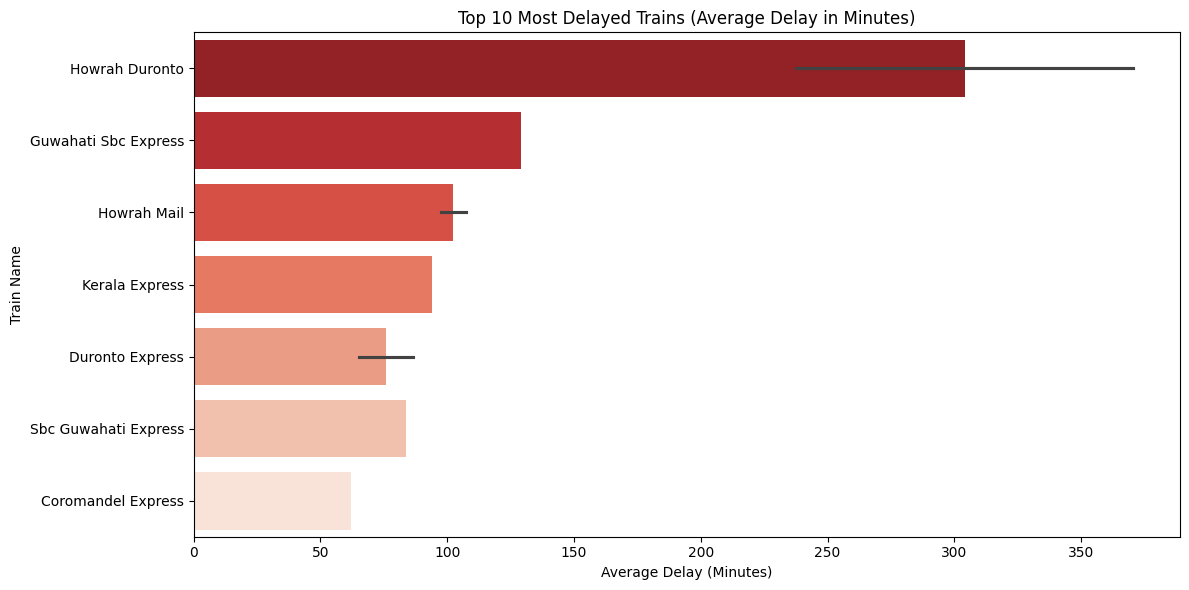

In [4]:
# Most delayed trains
top_delayed = df.groupby(['train_number', 'train_name'])['average_delay_minutes'].mean().reset_index()
top_delayed = top_delayed.sort_values('average_delay_minutes', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_delayed, x='average_delay_minutes', y='train_name', palette='Reds_r')
plt.title('Top 10 Most Delayed Trains (Average Delay in Minutes)')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Train Name')
plt.tight_layout()
plt.show()

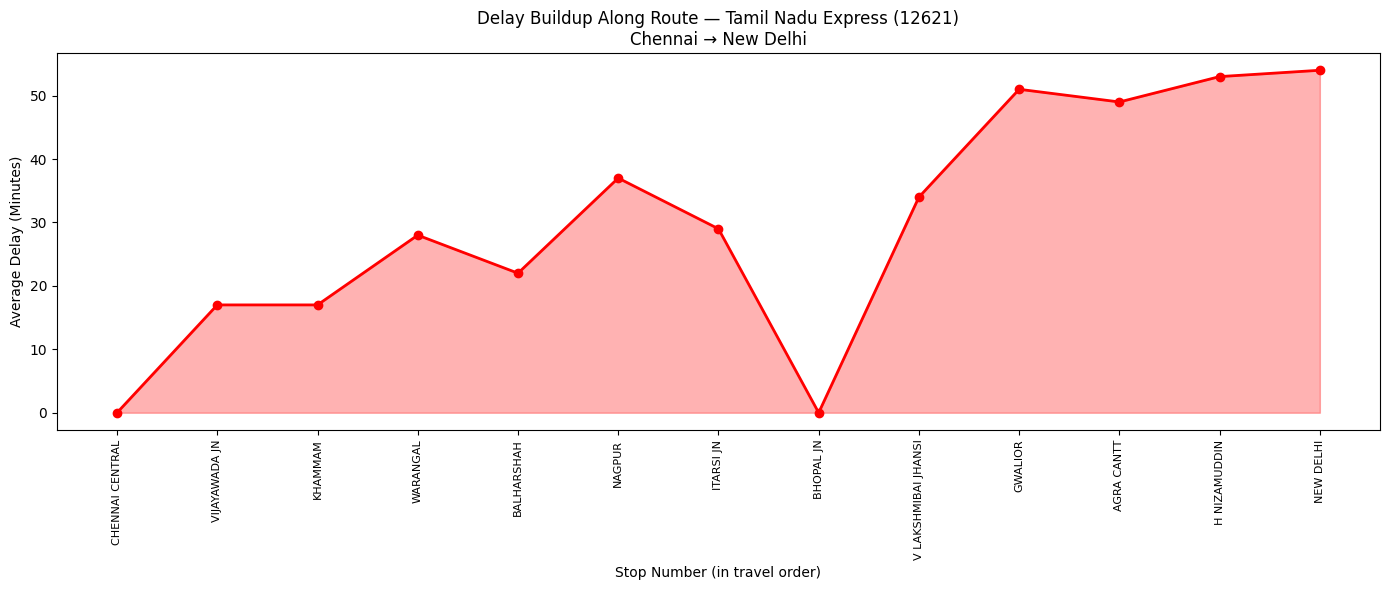

In [5]:
# Delay buildup along route - Tamil Nadu Express
train_route = df[df['train_number'] == 12621].sort_values('stop_order')

plt.figure(figsize=(14, 6))
plt.plot(train_route['stop_order'], train_route['average_delay_minutes'], 
         marker='o', color='red', linewidth=2, markersize=6)
plt.fill_between(train_route['stop_order'], train_route['average_delay_minutes'], 
                 alpha=0.3, color='red')
plt.title('Delay Buildup Along Route — Tamil Nadu Express (12621)\nChennai → New Delhi')
plt.xlabel('Stop Number (in travel order)')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(train_route['stop_order'], train_route['station_name'], 
           rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_13940\1977782052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_avg, x='train_type', y='average_delay_minutes',


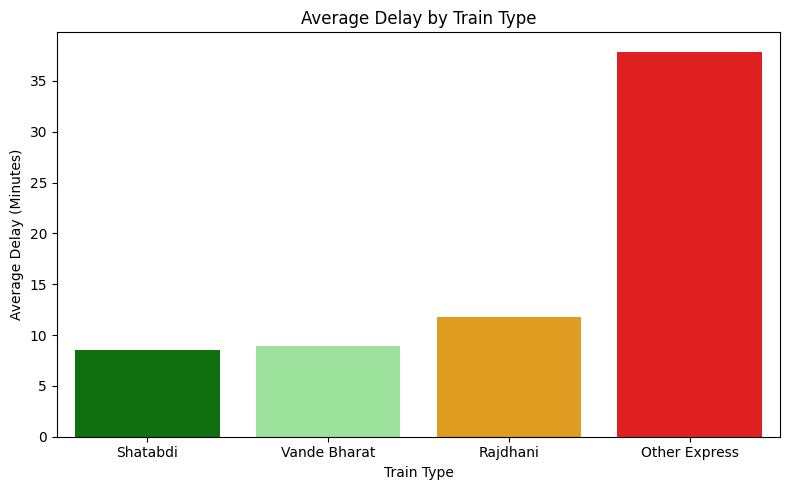

In [6]:
# Train type comparison
df['train_type'] = 'Other Express'
df.loc[df['train_name'].str.contains('Rajdhani', na=False), 'train_type'] = 'Rajdhani'
df.loc[df['train_name'].str.contains('Vande Bharat', na=False), 'train_type'] = 'Vande Bharat'
df.loc[df['train_name'].str.contains('Shatabdi', na=False), 'train_type'] = 'Shatabdi'

type_avg = df.groupby('train_type')['average_delay_minutes'].mean().reset_index()
type_avg = type_avg.sort_values('average_delay_minutes')

plt.figure(figsize=(8, 5))
sns.barplot(data=type_avg, x='train_type', y='average_delay_minutes', 
            palette=['green', 'lightgreen', 'orange', 'red'])
plt.title('Average Delay by Train Type')
plt.xlabel('Train Type')
plt.ylabel('Average Delay (Minutes)')
plt.tight_layout()
plt.show()